In [1]:
import pandas as pd
import matplotlib.pyplot as plt

customer_df = pd.read_csv("Customer_Insights.csv")
fulfillment_df = pd.read_csv("Fulfillment_Insights.csv")
location_df = pd.read_csv("Location_Insights.csv")
order_status_df = pd.read_csv("Order_Status_Summary.csv")
payment_df = pd.read_csv("Payment_Analysis.csv")
product_df = pd.read_csv("Product_Performance.csv")
sales_df = pd.read_csv("Sales_Performance.csv")

## Customer Insights Analysis
Total Spending by Income Bracket

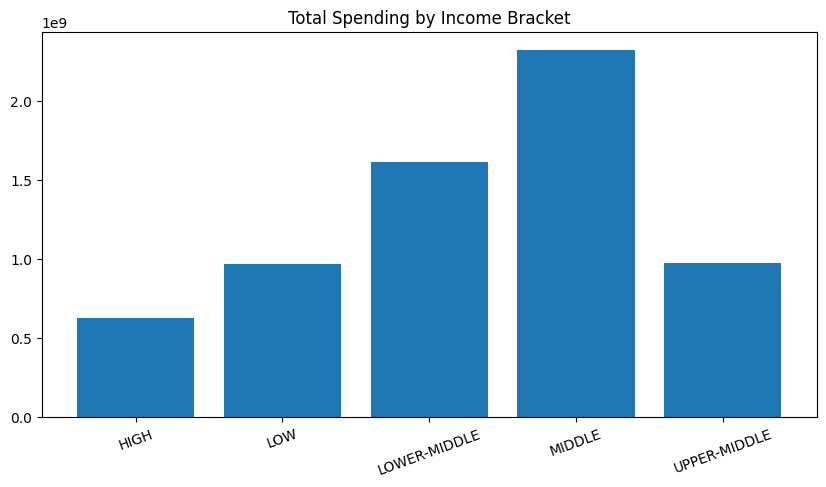

In [2]:
income_df = customer_df.groupby(
    "INCOME_BRACKET"
)["TOTAL_SPENT"].sum()

plt.figure(figsize=(10,5))

plt.bar(
    income_df.index,
    income_df.values
)

plt.title("Total Spending by Income Bracket")
plt.xticks(rotation=20)
plt.show()

Orders by Gender

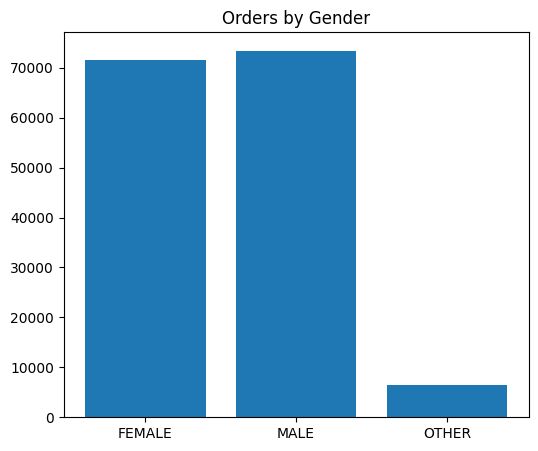

In [3]:
gender_df = customer_df.groupby(
    "GENDER"
)["TOTAL_ORDERS"].sum()

plt.figure(figsize=(6,5))

plt.bar(
    gender_df.index,
    gender_df.values
)

plt.title("Orders by Gender")
plt.show()

Age Group Analysis

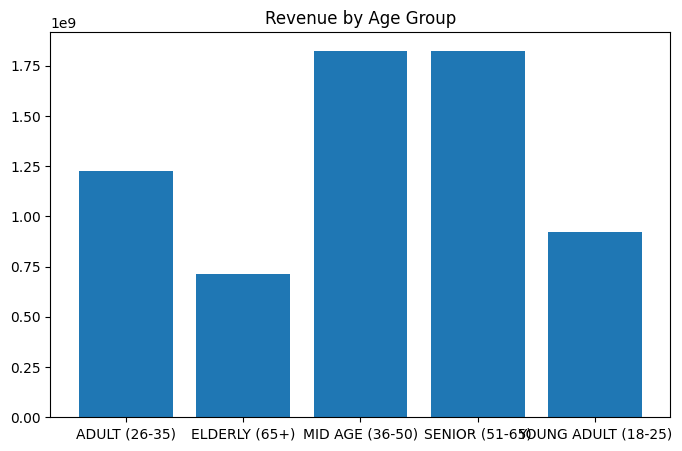

In [4]:
age_df = customer_df.groupby(
    "AGE_GROUP"
)["TOTAL_SPENT"].sum()

plt.figure(figsize=(8,5))

plt.bar(
    age_df.index,
    age_df.values
)

plt.title("Revenue by Age Group")
plt.show()

## Fulfillment Insights
Orders by Shipping Method

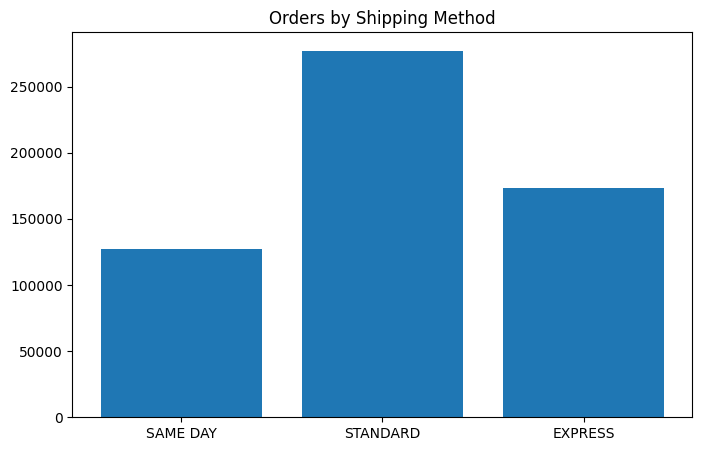

In [5]:
plt.figure(figsize=(8,5))

plt.bar(
    fulfillment_df["SHIPPING_METHOD"],
    fulfillment_df["TOTAL_ORDERS"]
)

plt.title("Orders by Shipping Method")
plt.show()

Shipping Revenue

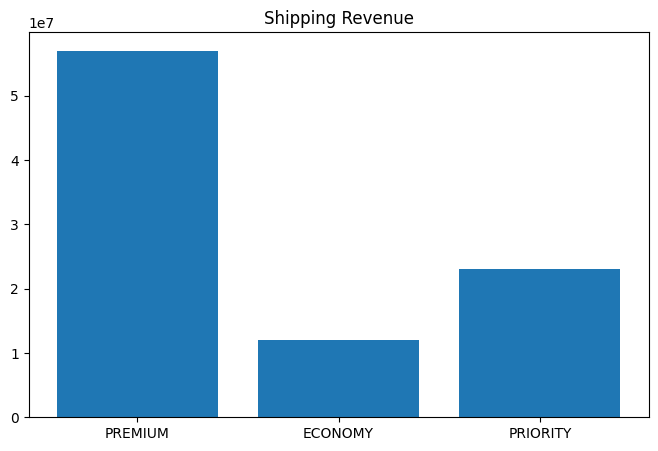

In [6]:
plt.figure(figsize=(8,5))

plt.bar(
    fulfillment_df["SERVICE_LEVEL"],
    fulfillment_df["SHIPPING_REVENUE"]
)

plt.title("Shipping Revenue")
plt.show()

## Location Insights
Revenue by Region

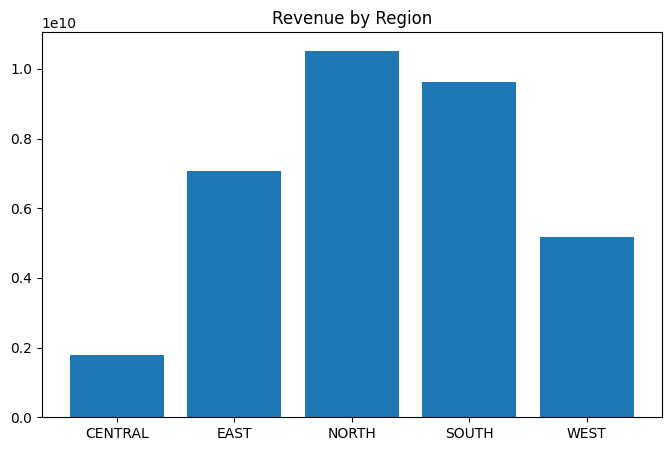

In [7]:
region_df = location_df.groupby(
    "REGION"
)["TOTAL_REVENUE"].sum()

plt.figure(figsize=(8,5))

plt.bar(
    region_df.index,
    region_df.values
)

plt.title("Revenue by Region")
plt.show()

Orders by Area Type

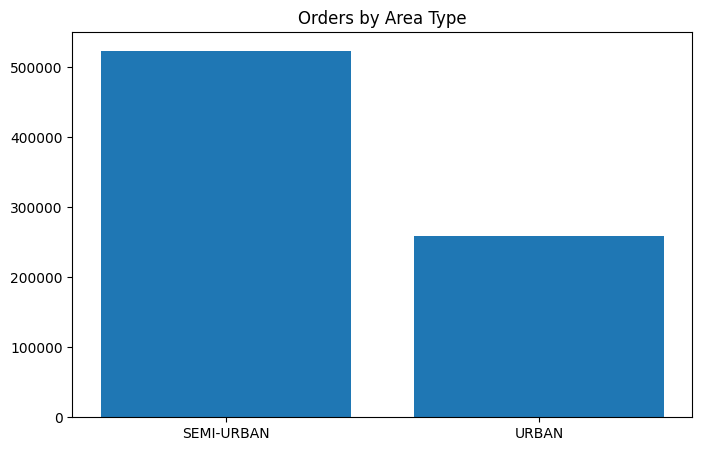

In [8]:
area_df = location_df.groupby(
    "AREA_TYPE"
)["TOTAL_ORDERS"].sum()

plt.figure(figsize=(8,5))

plt.bar(
    area_df.index,
    area_df.values
)

plt.title("Orders by Area Type")
plt.show()

## Order Status Analysis

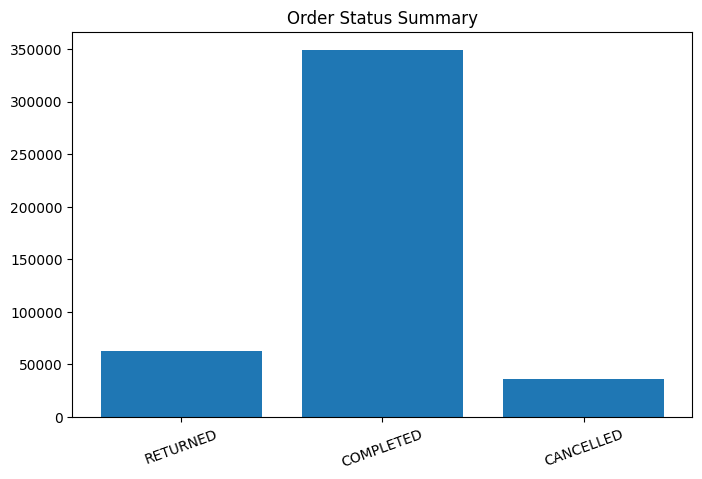

In [9]:
plt.figure(figsize=(8,5))

plt.bar(
    order_status_df["ORDER_STATUS"],
    order_status_df["TOTAL_ORDERS"]
)

plt.title("Order Status Summary")
plt.xticks(rotation=20)
plt.show()

## Payment Analysis
Orders by Payment Method

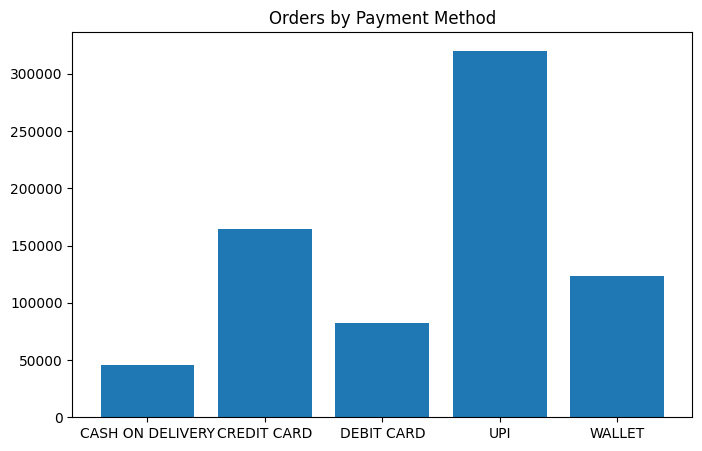

In [10]:
payment_method = payment_df.groupby(
    "PAYMENT_METHOD"
)["TOTAL_ORDERS"].sum()

plt.figure(figsize=(8,5))

plt.bar(
    payment_method.index,
    payment_method.values
)

plt.title("Orders by Payment Method")
plt.show()

Orders by Payment Provider

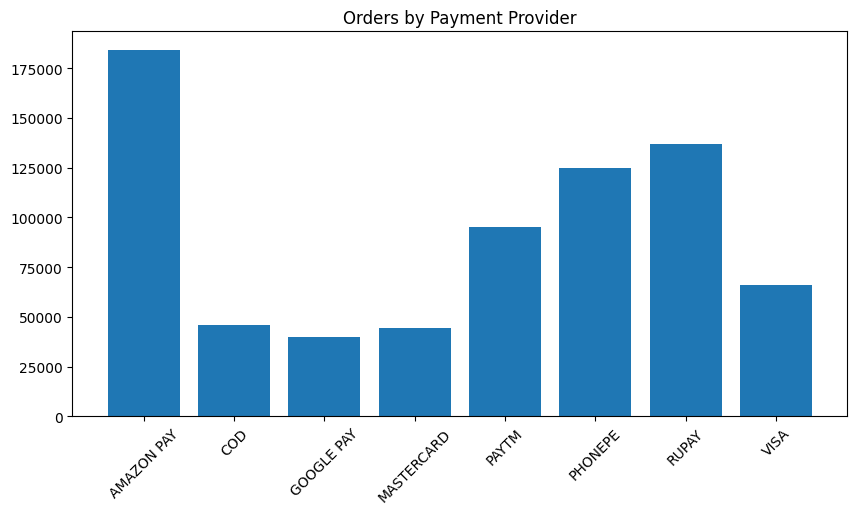

In [11]:
provider_df = payment_df.groupby(
    "PAYMENT_PROVIDER"
)["TOTAL_ORDERS"].sum()

plt.figure(figsize=(10,5))

plt.bar(
    provider_df.index,
    provider_df.values
)

plt.title("Orders by Payment Provider")
plt.xticks(rotation=45)
plt.show()

## Product Performance
Top 10 Products

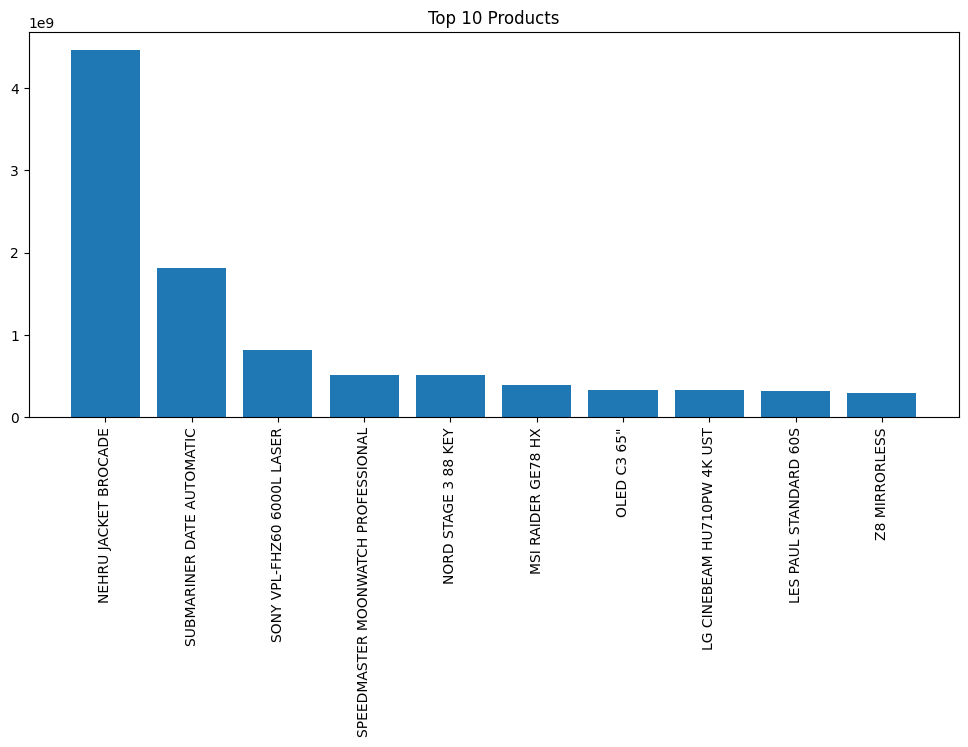

In [14]:
top_product = product_df.sort_values(
    by="NET_REVENUE",
    ascending=False
).head(10)

plt.figure(figsize=(12,5))

plt.bar(
    top_product["PRODUCT_NAME"],
    top_product["NET_REVENUE"]
)

plt.title("Top 10 Products")
plt.xticks(rotation=90)
plt.show()

Quantity Sold by Brand

In [21]:
brand_df = product_df.groupby(
    "BRAND"
)["TOTAL_QUANTITY_SOLD"].sum().sort_values(ascending=False)

brand_df

,TOTAL_QUANTITY_SOLD
BRAND,
FRESHO,65898
AMUL,27314
HIMALAYA,25562
BRITANNIA,19594
STAEDTLER,15905
...,...
SONOR,378
SHOEI,373
TAYLOR,371


## Sales Performance
Daily Revenue Trend

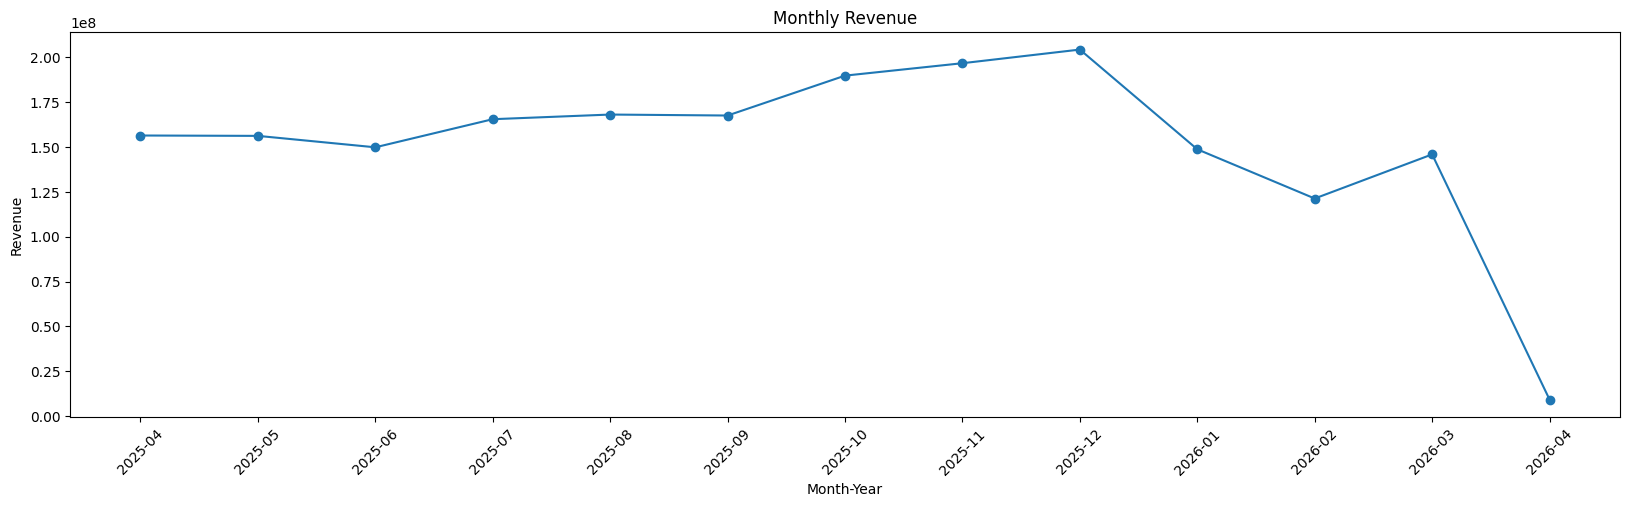

In [25]:
sales_df["ORDER_DATE"] = pd.to_datetime(sales_df["ORDER_DATE"])

monthly_sales = sales_df.groupby(
    sales_df["ORDER_DATE"].dt.to_period("M")
)["FINAL_REVENUE"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(20,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.xlabel("Month-Year")
plt.ylabel("Revenue")

plt.show()

Revenue by Category

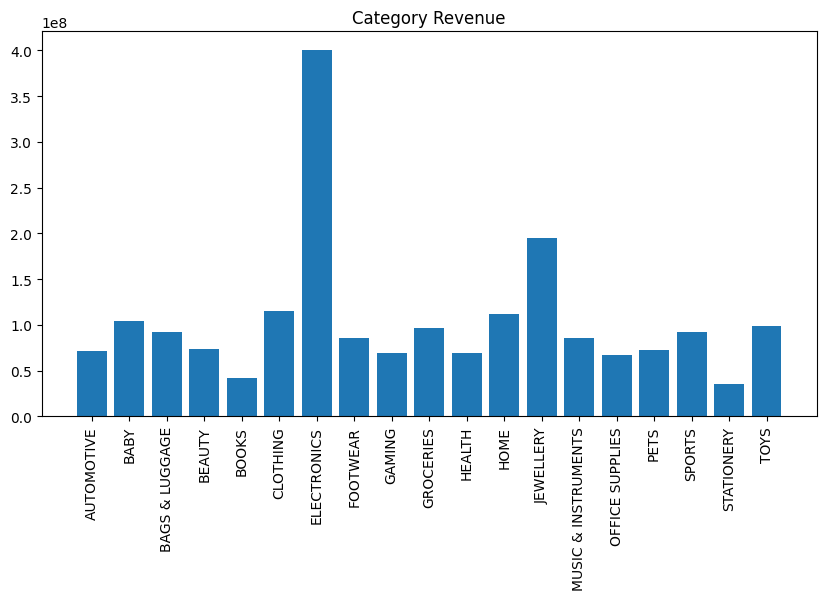

In [27]:
sales_category = sales_df.groupby(
    "CATEGORY"
)["FINAL_REVENUE"].sum()

plt.figure(figsize=(10,5))

plt.bar(
    sales_category.index,
    sales_category.values
)

plt.title("Category Revenue")
plt.xticks(rotation=90)
plt.show()

## Business Insights
Top Spending Customers

In [32]:
customer_df.sort_values(
    by="TOTAL_SPENT",
    ascending=False
)[['CUSTOMER_ID',	'FULL_NAME','TOTAL_REFUND','LAST_PURCHASE_DATE']].head()

,CUSTOMER_ID,FULL_NAME,TOTAL_REFUND,LAST_PURCHASE_DATE
4530,CUST029691,Kanav Jhaveri,1832349.76,2025-12-27
943,CUST016243,Ivana Bhat,2741.97,2026-03-26
14172,CUST009939,Gokul Batta,0.00,2026-02-12
15102,CUST050410,Biju Sengupta,36436.84,2026-01-27
8283,CUST009908,Hazel Varma,0.00,2026-03-07


Best Selling Products

In [33]:
product_df.sort_values(
    by="TOTAL_QUANTITY_SOLD",
    ascending=False
)[['PRODUCT_ID','PRODUCT_NAME','CATEGORY','SUB_CATEGORY','TOTAL_ORDERS','TOTAL_QUANTITY_SOLD','GROSS_REVENUE']].head()

,PRODUCT_ID,PRODUCT_NAME,CATEGORY,SUB_CATEGORY,TOTAL_ORDERS,TOTAL_QUANTITY_SOLD,GROSS_REVENUE
797,PROD000615,KURKURE MASALA MUNCH 100G,GROCERIES,SNACKS,1855,13993,799266.51
1100,PROD000666,TABLE SALT IODIZED 1KG,GROCERIES,STAPLES,1595,11630,1007437.76
1132,PROD000656,PITA BREAD 6 PIECES,GROCERIES,BAKERY,1486,10048,1713958.68
1123,PROD000629,BEETROOT 1KG,GROCERIES,VEGETABLES,1299,9869,1388140.64
161,PROD000613,BRITANNIA NUTRICHOICE OATMEAL COOKIES,GROCERIES,SNACKS,1079,9363,1295750.64
